Дана таблица с данными о ежедневной выработке энергии солнечными батареями. Информация содержится в двух столбцах:

* `date` — дата наблюдения;
* `cum_power` — накопленная (кумулятивная) выработка энергии на указанный день.
Таким образом, перед вами классический пример временного ряда — числовой показатель, зависящий от времени. Давайте с ним поработаем.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

solar_data = pd.read_csv('data/solarpower.csv')
solar_data.head()

,date,cum_power
0,2017-01-01,20111.0
1,2017-01-02,20112.0
2,2017-01-03,20115.0
3,2017-01-04,20117.0
4,2017-01-05,20119.0


В нашем временном ряде есть несколько пропусков, они обозначены числом -1. Заполните пропуски средним арифметическим между двумя соседними наблюдениями.



In [11]:
# Заменяем пропуски на NaN
solar_data['cum_power'] = solar_data['cum_power'].replace(-1, np.nan)

# Производим интерполяцию, то есть заполняем пропуски средним между двумя наблюдениями
solar_data['cum_power'] = solar_data['cum_power'].interpolate()

# Находим среднее после замены пропусков
display(round(solar_data['cum_power'].mean()))

23848

Теперь, когда таблица заполнена, создайте столбец `day_power` — ежедневная выработка солнечной энергии.

Далее создайте данные о средней ежедневной выработке энергии на каждый месяц-год.

In [15]:
# Работаем со столбцом даты
solar_data['date'] = pd.to_datetime(solar_data['date'])

# Вычисляем ежедневную выработку как разницу между кумулятивной выработки по дням
solar_data['day_power'] = solar_data['cum_power'].diff()
# Так как у первого дня нет предыдущего значения, заполняем 0
solar_data['day_power'] = solar_data['day_power'].fillna(0)

# Группируем по месяцам и вычисление среднего
monthly_power = solar_data.groupby(solar_data['date'].dt.to_period('M'))['day_power'].mean()

print(round(monthly_power))



date
2017-01     3.0
2017-02     4.0
2017-03    11.0
2017-04    16.0
2017-05    19.0
2017-06    22.0
2017-07    18.0
2017-08    15.0
2017-09    12.0
2017-10     6.0
2017-11     3.0
2017-12     1.0
2018-01     2.0
2018-02     7.0
2018-03     9.0
2018-04    15.0
2018-05    21.0
2018-06    19.0
2018-07    22.0
2018-08    17.0
2018-09    14.0
2018-10     9.0
Freq: M, Name: day_power, dtype: float64


Постройте график временного ряда — средней ежедневной выработки солнечной энергии на каждый месяц-год. Не забудьте подписать оси и сам график.

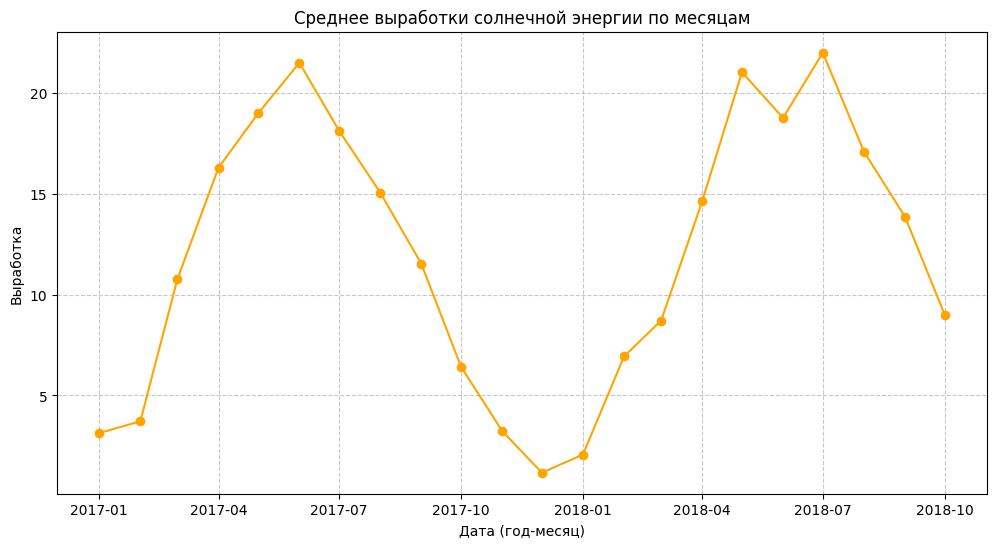

In [18]:
# Приводим PeriodIndex к DatetimeIndex для корректного отображения
# чтобы не было ошибки TypeError: float() argument must be a string or a real number, not 'Period'
monthly_data = monthly_power.to_timestamp()

fig = plt.figure(figsize=(12,6))
plt.plot(monthly_data.index, 
         monthly_data.values, 
         marker='o',
         linestyle='-',
         color='orange'
)

plt.title('Среднее выработки солнечной энергии по месяцам')
plt.xlabel('Дата (год-месяц)')
plt.ylabel('Выработка')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()